## Homework 4: Unsupervised Learning

### Exercise 2: Best Rank-k Approximation

In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def build_matrix(m=10, n=6, kind="structured", seed=0):
    rng = np.random.default_rng(seed)

    if kind == "random":
        return rng.normal(0, 1, size=(m, n))

    if kind == "structured":
        r = min(3, m, n)  # true-ish rank (before noise)
        B = rng.normal(0, 1, size=(m, r))
        C = rng.normal(0, 1, size=(n, r))
        A0 = B @ C.T
        noise = 1e-3 * rng.normal(0, 1, size=(m, n))
        return A0 + noise
    
def compute_svd(A):
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    return U, s, Vt

def frobenius_norm(M):
    return np.linalg.norm(M, ord="fro")

In [7]:
def best_rank_k_approx(U, s, Vt, k):
    """
    Build Ak = sum_{i=1..k} sigma_i u_i v_i^T
    using truncated SVD pieces.

    Shapes (reduced SVD):
      U:  (m, r)
      s:  (r,)
      Vt: (r, n)
      where r = min(m, n)

    Ak = U_k diag(s_k) Vt_k
    """
    k = int(k)
    if k < 0:
        raise ValueError("k must be >= 0")
    r = len(s)
    k = min(k, r)

    if k == 0:
        m = U.shape[0]
        n = Vt.shape[1]
        return np.zeros((m, n), dtype=float)

    Uk = U[:, :k]
    sk = s[:k]
    Vtk = Vt[:k, :]
    Ak = Uk @ np.diag(sk) @ Vtk
    return Ak

def approximation_error_vs_k(A, U, s, Vt, ks=None):
    """
    Compute E(k) = ||A - Ak||_F for several k.
    If ks is None, use k=0..r (inclusive).
    """
    r = len(s)
    if ks is None:
        ks = list(range(0, r + 1))

    E = []
    for k in ks:
        Ak = best_rank_k_approx(U, s, Vt, k)
        E.append(frobenius_norm(A - Ak))
    return np.array(ks, dtype=int), np.array(E, dtype=float)

In [8]:
def plot_Ek(ks, Ek, title="Approximation error E(k) vs k"):
    plt.figure(figsize=(7, 4))
    plt.plot(ks, Ek, marker="o")
    plt.title(title)
    plt.xlabel("k (rank)")
    plt.ylabel("E(k) = ||A - Ak||_F")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
    
def run_ex2_rank_k(m=10, n=6, kind="structured", seed=0, ks=None):
    A = build_matrix(m=m, n=n, kind=kind, seed=seed)
    U, s, Vt = compute_svd(A)

    ks, Ek = approximation_error_vs_k(A, U, s, Vt, ks=ks)

    print(f"A shape = {A.shape}, r = min(m,n) = {len(s)}")
    print("E(k) values:")
    for k, e in zip(ks, Ek):
        print(f"  k={k:2d}  E(k)={e:.6e}")

    plot_Ek(ks, Ek, title=f"E(k) vs k (A: {m}x{n}, kind={kind})")
    return A, U, s, Vt, ks, Ek

A shape = (10, 6), r = min(m,n) = 6
E(k) values:
  k= 0  E(k)=1.075854e+01
  k= 1  E(k)=5.174818e+00
  k= 2  E(k)=3.058120e+00
  k= 3  E(k)=4.769485e-03
  k= 4  E(k)=3.494355e-03
  k= 5  E(k)=2.171267e-03
  k= 6  E(k)=4.055283e-15


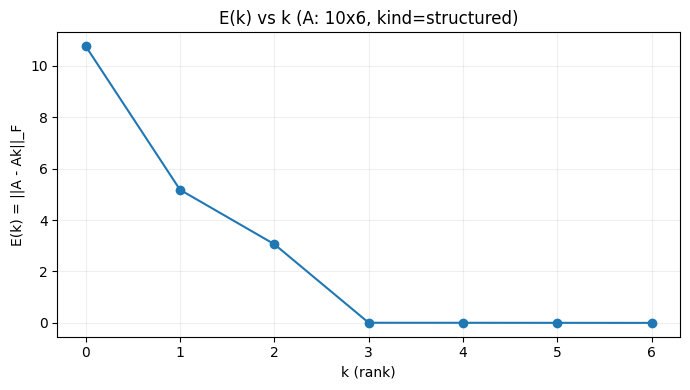

(array([[-0.19947607,  0.26854696,  0.4373496 ,  1.32244087,  0.2353611 ,
          1.02396909],
        [-0.05272345,  0.07064458,  0.28475487,  1.37922734, -0.18290037,
         -0.10578955],
        [-1.40303255,  0.65730414, -1.52531894, -0.31090013,  2.30920899,
         -0.40825315],
        [ 1.40296966, -0.80218268,  0.94118554, -1.04471557, -2.17909019,
         -0.42980911],
        [ 2.59254336, -1.74782891,  0.57358841, -5.08433496, -3.63029589,
         -2.03049481],
        [ 0.90356807, -0.62327577,  0.30153769, -0.88782067, -1.49480131,
         -1.18478658],
        [-0.61446975,  0.40136626, -0.50444662, -0.89114791,  1.33378468,
          1.1405138 ],
        [-1.29672047,  0.72274712, -0.53207213,  3.40966676,  1.41257402,
         -0.70874966],
        [-0.81328032,  0.24401358, -1.18712632,  0.10390015,  1.09329131,
         -1.6030089 ],
        [ 0.9911109 , -0.51958915,  0.83547855, -0.46814834, -1.54063517,
          0.05423724]]),
 array([[-0.12912559, -0.274

In [9]:
run_ex2_rank_k(m=10, n=6, kind="structured", seed=0)